# Unified Analysis Notebook

This notebook orchestrates compute-only pipeline modules in `analysis_pipeline`.
Heavy computations live in `.py` files; this notebook focuses on configuration, execution, validation, and plotting.

## 1. Set Up Environment and Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis_pipeline.config import load_analysis_config, merge_overrides
from analysis_pipeline.pipeline import run_bead_core, run_autocorr_core

plt.style.use('./science.mplstyle.txt')
plt.style.use('dark_background')
pd.set_option('display.max_columns', 200)

ROOT = Path('.')
print('Workspace:', ROOT.resolve())

Workspace: /Users/tom/Uni_local/master_local/analysis


## 2. Define Project Configuration

In [2]:
config_path = ROOT / 'config' / 'analysis_default.yaml'
base_config = load_analysis_config(str(config_path))

# Notebook overrides for rapid iteration.
quick_test_mode = True
quick_test_frames = 5

overrides = {
    'dataset': {
        # 'dataset_id': 'AMF_101_003__C640_C470',
        # 'base_dir': '/Volumes/TOM_DATA',
    },
    'runtime': {
        'skip_existing': not quick_test_mode,
        'verbose': True,
    },
    'beads': {
        # 'channel_to_use': 1,
    },
    'autocorr': {
        # 'single_frame_3d': 0,
    }
}

# Fast subset mode for parameter tuning before full runs.
if quick_test_mode:
    overrides.setdefault('dataset', {})['tstop'] = int(quick_test_frames)

config = merge_overrides(base_config, overrides)
print('Dataset ID:', config['dataset']['dataset_id'])
print('Base dir:', config['dataset']['base_dir'])
print('Quick test mode:', quick_test_mode, '| tstop:', config['dataset'].get('tstop'))

Dataset ID: AMF_101_003__C640_C470
Base dir: /Volumes/TOM_DATA
Quick test mode: True | tstop: 5


## 3. Load and Validate Input Data

In [3]:
dataset_id = config['dataset']['dataset_id']
assert isinstance(dataset_id, str) and len(dataset_id) > 0, 'dataset.dataset_id must be non-empty'

base_dir = Path(config['dataset']['base_dir'])
if not base_dir.exists():
    print('Warning: base_dir does not exist locally:', base_dir)

print('Config validation passed')
print('Bead stage enabled:', bool(config['beads']['enabled']))
print('Autocorr stage enabled:', bool(config['autocorr']['enabled']))
print('Frame subset (tstop):', config['dataset'].get('tstop'))

Config validation passed
Bead stage enabled: True
Autocorr stage enabled: True
Frame subset (tstop): 5


## 4. Preprocess Data for Implementation

In [4]:
# Pipeline modules handle heavy preprocessing internally.
# This cell prepares notebook-level runtime toggles and expected output paths.

derived_dir = Path('data') / dataset_id / 'derived'
derived_dir.mkdir(parents=True, exist_ok=True)

expected_outputs = {
    'detections': derived_dir / 'beads_detections.parquet',
    'tracks': derived_dir / 'beads_tracks.parquet',
    'tracks_vel': derived_dir / 'beads_tracks_with_velocity.parquet',
    'tracks_ang': derived_dir / 'beads_tracks_with_angular_speed.parquet',
    'ac3d_single': derived_dir / 'autocorr_3d_single_frame.parquet',
    'ac3d_sampled': derived_dir / 'autocorr_3d_sampled.parquet',
    'ac2d_sampled': derived_dir / 'autocorr_2d_sampled.parquet',
    'ac2d_radial': derived_dir / 'autocorr_2d_radial_single.parquet',
}

pd.DataFrame({'artifact': list(expected_outputs.keys()), 'path': [str(v) for v in expected_outputs.values()]})

,artifact,path
0,detections,data/AMF_101_003__C640_C470/derived/beads_dete...
1,tracks,data/AMF_101_003__C640_C470/derived/beads_trac...
2,tracks_vel,data/AMF_101_003__C640_C470/derived/beads_trac...
3,tracks_ang,data/AMF_101_003__C640_C470/derived/beads_trac...
4,ac3d_single,data/AMF_101_003__C640_C470/derived/autocorr_3...
5,ac3d_sampled,data/AMF_101_003__C640_C470/derived/autocorr_3...
6,ac2d_sampled,data/AMF_101_003__C640_C470/derived/autocorr_2...
7,ac2d_radial,data/AMF_101_003__C640_C470/derived/autocorr_2...


## 5. Implement Core Functions

In [5]:
# Core reusable functions are implemented in analysis_pipeline/*.py.
# Here we add minimal notebook-side wrappers for convenience.

def summarize_track_table(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame({'metric': ['rows', 'particles'], 'value': [0, 0]})
    n_particles = int(df['particle'].nunique()) if 'particle' in df.columns else 0
    return pd.DataFrame({'metric': ['rows', 'particles'], 'value': [int(len(df)), n_particles]})


def summarize_autocorr_table(df: pd.DataFrame, corr_col: str = 'corr') -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame({'metric': ['rows', 'finite_corr'], 'value': [0, 0]})
    finite_corr = int(np.isfinite(df[corr_col]).sum()) if corr_col in df.columns else 0
    return pd.DataFrame({'metric': ['rows', 'finite_corr'], 'value': [int(len(df)), finite_corr]})

print('Notebook helper functions ready')

Notebook helper functions ready


## 6. Assemble and Run Initial Pipeline

In [6]:
bead_out = None
autocorr_out = None

if bool(config['beads']['enabled']):
    bead_out = run_bead_core(config)

if bool(config['autocorr']['enabled']):
    state_for_autocorr = bead_out['state'] if bead_out is not None else None
    autocorr_out = run_autocorr_core(config, state=state_for_autocorr)

print('Pipeline run complete')

Frame 4: 685 trajectories present.
Saved detections to data/AMF_101_003__C640_C470/derived/beads_detections.parquet | rows=3438
Saved tracks to data/AMF_101_003__C640_C470/derived/beads_tracks.parquet | rows=3438
FOV shape yx=(2882,2882)
Saved tracks+velocity to data/AMF_101_003__C640_C470/derived/beads_tracks_with_velocity.parquet | rows=3438
Saved tracks+angular speed to data/AMF_101_003__C640_C470/derived/beads_tracks_with_angular_speed.parquet | rows=3438
Saved single-frame 3D autocorr to data/AMF_101_003__C640_C470/derived/autocorr_3d_single_frame.parquet


sampled 3d autocorr: 100%|██████████| 5/5 [16:25<00:00, 197.18s/it]


Saved sampled 3D autocorr to data/AMF_101_003__C640_C470/derived/autocorr_3d_sampled.parquet


sampled 2d autocorr: 100%|██████████| 5/5 [00:15<00:00,  3.10s/it]


Saved sampled 2D autocorr to data/AMF_101_003__C640_C470/derived/autocorr_2d_sampled.parquet
Saved radial 2D autocorr to data/AMF_101_003__C640_C470/derived/autocorr_2d_radial_single.parquet
Pipeline run complete


## 7. Compute Evaluation Metrics

In [7]:
# Reload artifacts from disk to keep notebook state independent of in-memory objects.
tracks_vel_df = pd.read_parquet(expected_outputs['tracks_vel']) if expected_outputs['tracks_vel'].exists() else pd.DataFrame()
ac3d_sampled_df = pd.read_parquet(expected_outputs['ac3d_sampled']) if expected_outputs['ac3d_sampled'].exists() else pd.DataFrame()
ac2d_sampled_df = pd.read_parquet(expected_outputs['ac2d_sampled']) if expected_outputs['ac2d_sampled'].exists() else pd.DataFrame()

metrics_rows = []
metrics_rows.append({'metric': 'tracks_vel_rows', 'value': int(len(tracks_vel_df))})
metrics_rows.append({'metric': 'tracks_vel_particles', 'value': int(tracks_vel_df['particle'].nunique()) if 'particle' in tracks_vel_df.columns and len(tracks_vel_df) else 0})
metrics_rows.append({'metric': 'tracks_vel_speed_finite', 'value': int(np.isfinite(tracks_vel_df['speed_um_s']).sum()) if 'speed_um_s' in tracks_vel_df.columns and len(tracks_vel_df) else 0})
metrics_rows.append({'metric': 'ac3d_sampled_rows', 'value': int(len(ac3d_sampled_df))})
metrics_rows.append({'metric': 'ac3d_finite_xi', 'value': int(np.isfinite(ac3d_sampled_df['xi_um']).sum()) if 'xi_um' in ac3d_sampled_df.columns and len(ac3d_sampled_df) else 0})
metrics_rows.append({'metric': 'ac2d_sampled_rows', 'value': int(len(ac2d_sampled_df))})
metrics_rows.append({'metric': 'ac2d_finite_xi', 'value': int(np.isfinite(ac2d_sampled_df['xi_um']).sum()) if 'xi_um' in ac2d_sampled_df.columns and len(ac2d_sampled_df) else 0})

metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,metric,value
0,tracks_vel_rows,3438
1,tracks_vel_particles,3017
2,tracks_vel_speed_finite,421
3,ac3d_sampled_rows,600
4,ac3d_finite_xi,600
5,ac2d_sampled_rows,600
6,ac2d_finite_xi,600


## 8. Plot Results for Quick Validation

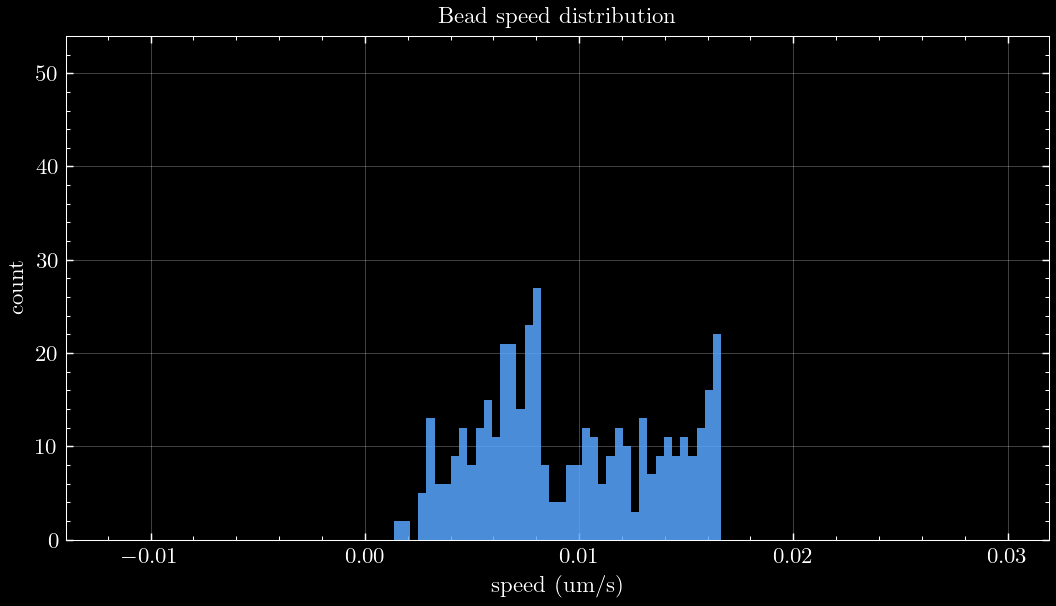

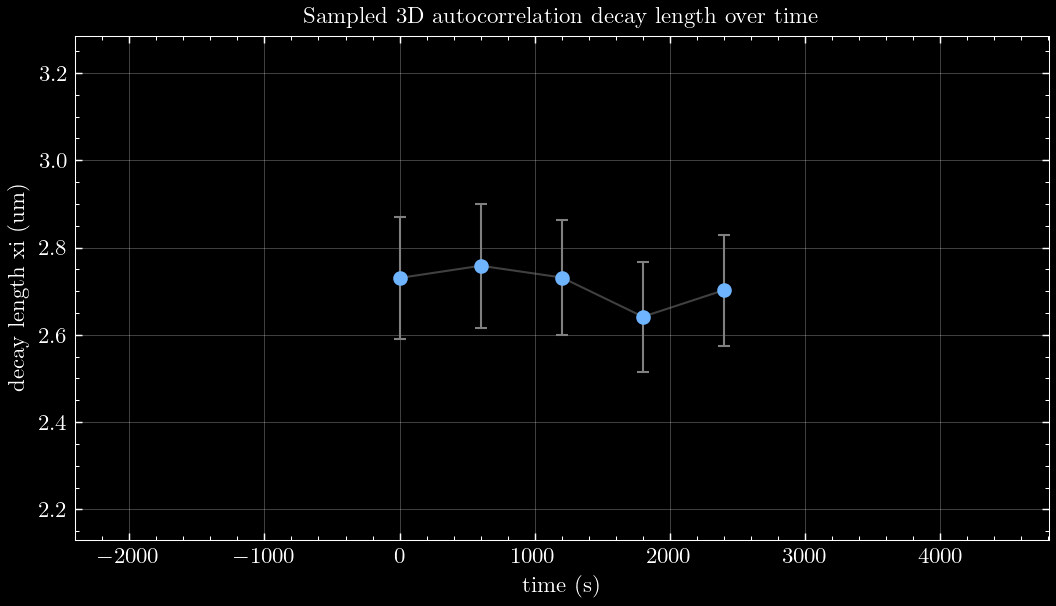

In [ ]:
plot_dir = Path('plots') / dataset_id / str(config['dataset'].get('variation', ''))
plot_dir.mkdir(parents=True, exist_ok=True)


def _save_dual_pdf(fig, stem: str):
    # Save dark version exactly as rendered in notebook.
    out_dark = plot_dir / f"{stem}_black.pdf"
    fig.savefig(out_dark, dpi=150, bbox_inches='tight')


def _save_dual_replot(stem: str, plot_fn):
    # Re-plot in default style for paper-friendly white background output.
    with plt.style.context('default'):
        fig_w, ax_w = plt.subplots(figsize=(7, 4), dpi=150)
        plot_fn(ax_w)
        fig_w.savefig(plot_dir / f"{stem}_white.pdf", dpi=150, bbox_inches='tight')
        plt.close(fig_w)


def _ordered_hot_colors(n: int):
    if n <= 0:
        return np.empty((0, 4))
    cmap = plt.get_cmap('hot')
    return np.array([cmap(i / max(1, n - 1)) for i in range(n)])


def _legend_scale(fig):
    width, height = fig.get_size_inches()
    base = min(width, height)
    fontsize = max(10, min(16, int(round(base * 1.4))))
    return {
        'fontsize': fontsize,
        'title_fontsize': fontsize,
        'handlelength': 2.2,
        'labelspacing': 0.6,
        'borderpad': 0.8,
        'handletextpad': 0.7,
        'columnspacing': 1.2,
    }


# Plot A: speed distribution
if len(tracks_vel_df) and 'speed_um_s' in tracks_vel_df.columns:
    speed_vals = tracks_vel_df['speed_um_s'].to_numpy(dtype=float)
    speed_vals = speed_vals[np.isfinite(speed_vals)]
else:
    speed_vals = np.array([])

if speed_vals.size > 0:
    fig_speed, ax_speed = plt.subplots(figsize=(7, 4), dpi=150)
    ax_speed.hist(speed_vals, bins=40, color=plt.get_cmap('hot')(0.72), alpha=0.9)
    ax_speed.set_xlabel('speed (um/s)')
    ax_speed.set_ylabel('count')
    ax_speed.set_title('Bead speed distribution')
    ax_speed.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    _save_dual_pdf(fig_speed, f"{dataset_id}_speed_distribution")

    def _speed_plot_white(ax):
        ax.hist(speed_vals, bins=40, color=plt.get_cmap('hot')(0.72), alpha=0.9)
        ax.set_xlabel('speed (um/s)')
        ax.set_ylabel('count')
        ax.set_title('Bead speed distribution')
        ax.grid(True, alpha=0.25)

    _save_dual_replot(f"{dataset_id}_speed_distribution", _speed_plot_white)
else:
    print('No finite speed values to plot')


# Plot B: sampled 3D decay length vs time (parity with old notebooks)
if len(ac3d_sampled_df) and {'time_s', 'xi_um'}.issubset(ac3d_sampled_df.columns):
    xi_3d = (
        ac3d_sampled_df[['time_s', 'frame', 'xi_um', 'xi_err_um']]
        .drop_duplicates(subset=['frame'])
        .sort_values('time_s')
    )
else:
    xi_3d = pd.DataFrame()

if len(xi_3d):
    x_3d = xi_3d['time_s'].to_numpy(dtype=float)
    y_3d = xi_3d['xi_um'].to_numpy(dtype=float)
    yerr_3d = xi_3d['xi_err_um'].to_numpy(dtype=float) if 'xi_err_um' in xi_3d.columns else None
    colors_3d = _ordered_hot_colors(len(x_3d))

    fig_decay3d, ax_decay3d = plt.subplots(figsize=(7, 4), dpi=150)
    for idx in range(len(x_3d)):
        ax_decay3d.errorbar(
            x_3d[idx],
            y_3d[idx],
            yerr=None if yerr_3d is None else yerr_3d[idx],
            fmt='o',
            color=colors_3d[idx],
            ecolor='gray',
            capsize=3,
        )
    ax_decay3d.plot(x_3d, y_3d, color='gray', alpha=0.5)
    ax_decay3d.set_xlabel('time (s)')
    ax_decay3d.set_ylabel('decay length xi (um)')
    ax_decay3d.set_title('Sampled 3D autocorrelation decay length over time')
    ax_decay3d.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    _save_dual_pdf(fig_decay3d, f"{dataset_id}_ac3d_decay_over_time")

    def _decay3d_plot_white(ax):
        for idx in range(len(x_3d)):
            ax.errorbar(
                x_3d[idx],
                y_3d[idx],
                yerr=None if yerr_3d is None else yerr_3d[idx],
                fmt='o',
                color=colors_3d[idx],
                ecolor='gray',
                capsize=3,
            )
        ax.plot(x_3d, y_3d, color='gray', alpha=0.5)
        ax.set_xlabel('time (s)')
        ax.set_ylabel('decay length xi (um)')
        ax.set_title('Sampled 3D autocorrelation decay length over time')
        ax.grid(True, alpha=0.25)

    _save_dual_replot(f"{dataset_id}_ac3d_decay_over_time", _decay3d_plot_white)
else:
    print('No sampled 3D decay data to plot')

## 9. Parity Plots (3D/2D Autocorr Profiles)

This section reproduces the core profile-style validation plots from the previous notebooks using saved compute outputs.

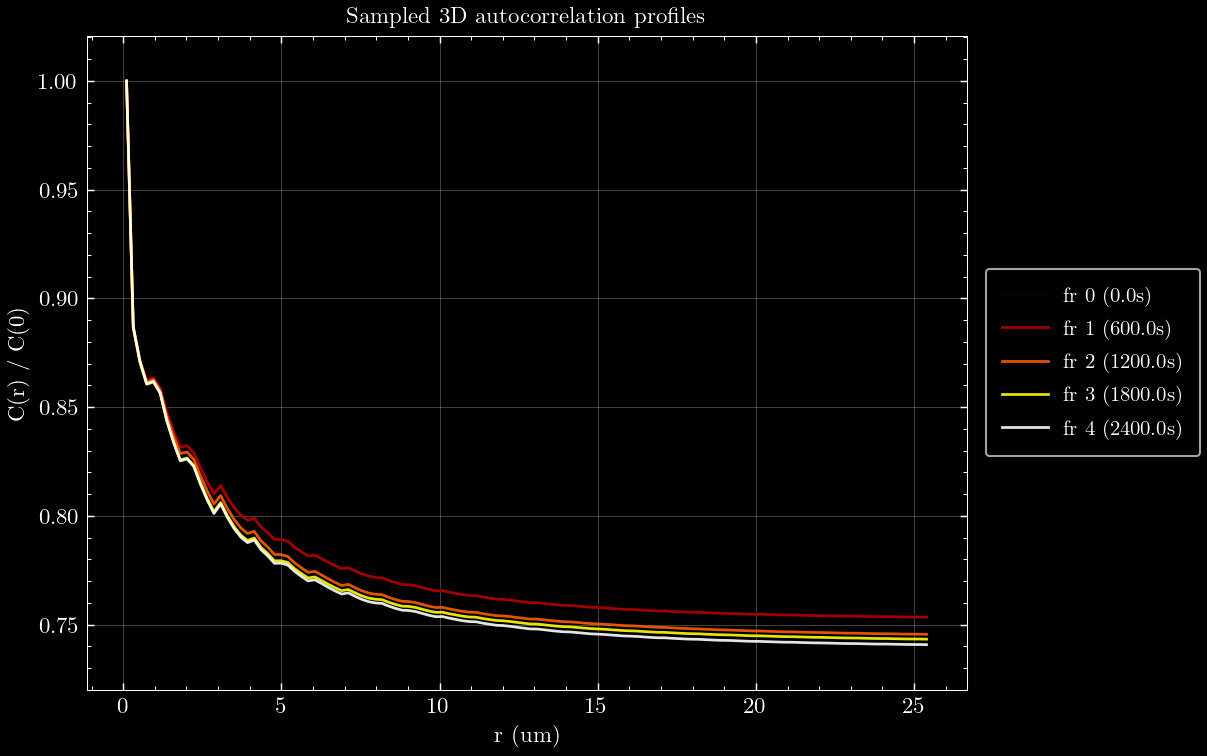

/var/folders/5l/j414w3bj3kb32xg7k44klyc40000gn/T/ipykernel_3635/3532384621.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_w.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=True, **_legend_scale(fig_w))


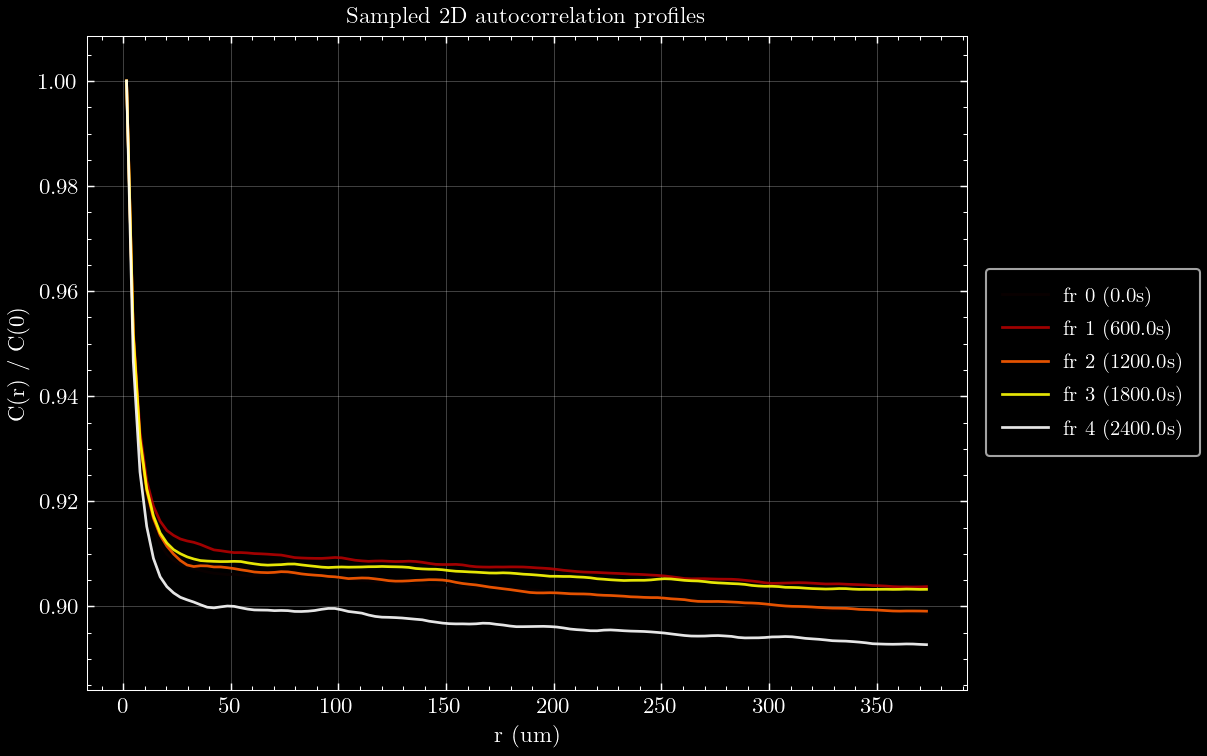

/var/folders/5l/j414w3bj3kb32xg7k44klyc40000gn/T/ipykernel_3635/3532384621.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_w2.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=True, **_legend_scale(fig_w2))


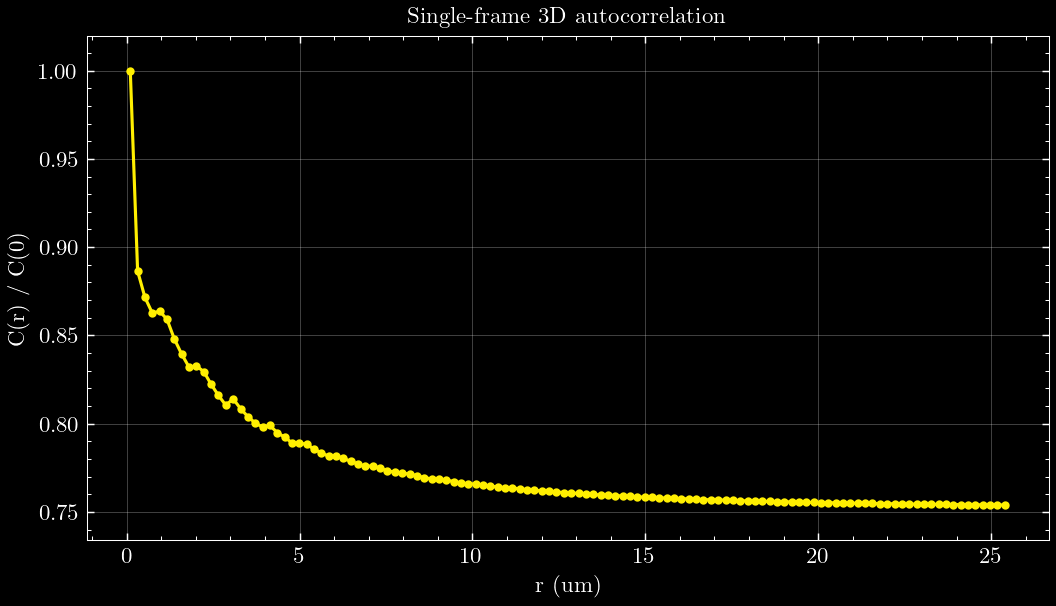

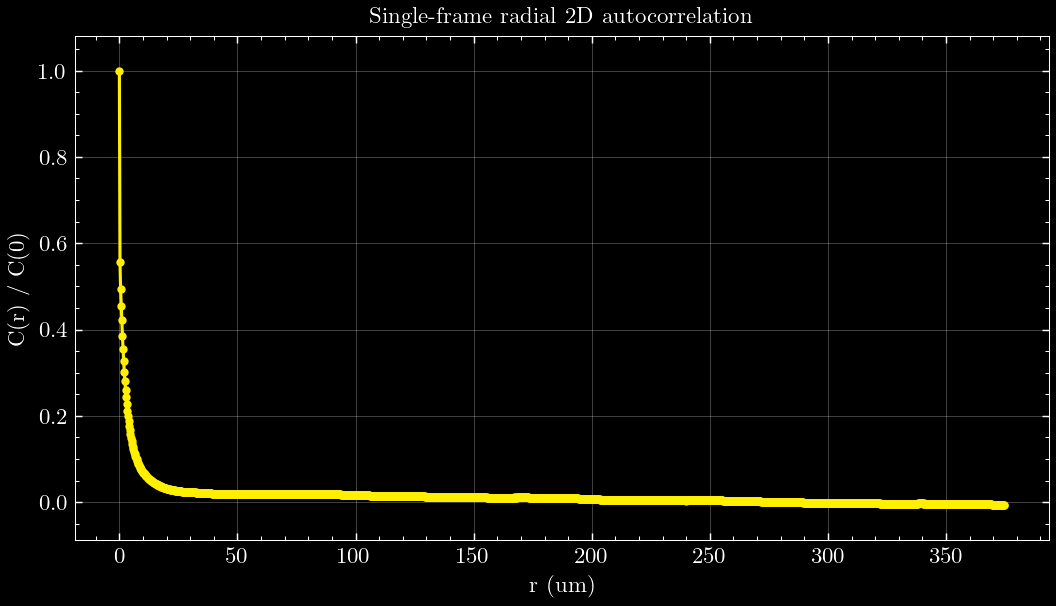

Saved metrics to data/AMF_101_003__C640_C470/derived/core_metrics_summary.parquet
Saved artifact manifest to data/AMF_101_003__C640_C470/derived/core_artifacts_manifest.parquet
Output directory: data/AMF_101_003__C640_C470/derived
Plot directory: plots/AMF_101_003__C640_C470


,artifact,exists,path
0,detections,True,data/AMF_101_003__C640_C470/derived/beads_dete...
1,tracks,True,data/AMF_101_003__C640_C470/derived/beads_trac...
2,tracks_vel,True,data/AMF_101_003__C640_C470/derived/beads_trac...
3,tracks_ang,True,data/AMF_101_003__C640_C470/derived/beads_trac...
4,ac3d_single,True,data/AMF_101_003__C640_C470/derived/autocorr_3...
5,ac3d_sampled,True,data/AMF_101_003__C640_C470/derived/autocorr_3...
6,ac2d_sampled,True,data/AMF_101_003__C640_C470/derived/autocorr_2...
7,ac2d_radial,True,data/AMF_101_003__C640_C470/derived/autocorr_2...


In [14]:
ac3d_single_df = pd.read_parquet(expected_outputs['ac3d_single']) if expected_outputs['ac3d_single'].exists() else pd.DataFrame()
ac2d_radial_df = pd.read_parquet(expected_outputs['ac2d_radial']) if expected_outputs['ac2d_radial'].exists() else pd.DataFrame()


def _apply_data_limits(ax, x_vals, y_vals, x_pad_frac=0.05, y_pad_frac=0.08, x_lower=None, x_upper=None):
    x = np.asarray(x_vals, dtype=float)
    y = np.asarray(y_vals, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    if not np.any(valid):
        return
    x = x[valid]
    y = y[valid]
    x_min = float(np.nanmin(x))
    x_max = float(np.nanmax(x))
    y_min = float(np.nanmin(y))
    y_max = float(np.nanmax(y))
    if x_max > x_min:
        x_pad = x_pad_frac * (x_max - x_min)
        left = x_min - x_pad if x_lower is None else max(x_lower, x_min - x_pad)
        right = x_max + x_pad if x_upper is None else min(x_upper, x_max + x_pad)
        ax.set_xlim(left, right)
    if y_max > y_min:
        y_pad = y_pad_frac * (y_max - y_min)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)


def _ordered_hot_colors(n: int):
    if n <= 0:
        return np.empty((0, 4))
    cmap = plt.get_cmap('hot')
    return np.array([cmap(i / max(1, n - 1)) for i in range(n)])


def _legend_scale(fig):
    width, height = fig.get_size_inches()
    base = min(width, height)
    fontsize = max(10, min(16, int(round(base * 1.4))))
    return {
        'fontsize': fontsize,
        'title_fontsize': fontsize,
        'handlelength': 2.2,
        'labelspacing': 0.6,
        'borderpad': 0.8,
        'handletextpad': 0.7,
        'columnspacing': 1.2,
    }


# 3D sampled autocorr profiles per sampled frame
if len(ac3d_sampled_df):
    fig_prof3d, ax_prof3d = plt.subplots(figsize=(8, 5), dpi=150)
    grouped_3d = list(ac3d_sampled_df.groupby('frame', sort=True))
    colors_3d = _ordered_hot_colors(len(grouped_3d))
    for (fr, g), color in zip(grouped_3d, colors_3d):
        g = g.sort_values('r_um')
        t_label = g['time_s'].iloc[0] if 'time_s' in g.columns else float(fr)
        ax_prof3d.plot(g['r_um'].to_numpy(), g['corr'].to_numpy(), lw=1.3, alpha=0.9, color=color, label=f'fr {fr} ({t_label:.1f}s)')
    ax_prof3d.set_xlabel('r (um)')
    ax_prof3d.set_ylabel('C(r) / C(0)')
    ax_prof3d.set_title('Sampled 3D autocorrelation profiles')
    ax_prof3d.grid(True, alpha=0.25)
    ax_prof3d.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=True, **_legend_scale(fig_prof3d))
    fig_prof3d.subplots_adjust(right=0.72)
    _apply_data_limits(ax_prof3d, ac3d_sampled_df['r_um'], ac3d_sampled_df['corr'])
    plt.tight_layout()
    plt.show()

    fig_prof3d.savefig(plot_dir / f"{dataset_id}_sampled_autocorr_profiles_black.pdf", dpi=150, bbox_inches='tight')
    with plt.style.context('default'):
        fig_w, ax_w = plt.subplots(figsize=(8, 5), dpi=150)
        for (fr, g), color in zip(grouped_3d, colors_3d):
            g = g.sort_values('r_um')
            ax_w.plot(g['r_um'].to_numpy(), g['corr'].to_numpy(), lw=1.3, alpha=0.9, color=color)
        ax_w.set_xlabel('r (um)')
        ax_w.set_ylabel('C(r) / C(0)')
        ax_w.set_title('Sampled 3D autocorrelation profiles')
        ax_w.grid(True, alpha=0.25)
        ax_w.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=True, **_legend_scale(fig_w))
        fig_w.subplots_adjust(right=0.72)
        _apply_data_limits(ax_w, ac3d_sampled_df['r_um'], ac3d_sampled_df['corr'])
        fig_w.savefig(plot_dir / f"{dataset_id}_sampled_autocorr_profiles_white.pdf", dpi=150, bbox_inches='tight')
        plt.close(fig_w)
else:
    print('No sampled 3D profiles available')

# 2D sampled autocorr profiles per sampled frame
if len(ac2d_sampled_df):
    fig_prof2d, ax_prof2d = plt.subplots(figsize=(8, 5), dpi=150)
    grouped_2d = list(ac2d_sampled_df.groupby('frame', sort=True))
    colors_2d = _ordered_hot_colors(len(grouped_2d))
    for (fr, g), color in zip(grouped_2d, colors_2d):
        g = g.sort_values('r_um')
        t_label = g['time_s'].iloc[0] if 'time_s' in g.columns else float(fr)
        ax_prof2d.plot(g['r_um'].to_numpy(), g['corr'].to_numpy(), lw=1.3, alpha=0.9, color=color, label=f'fr {fr} ({t_label:.1f}s)')
    ax_prof2d.set_xlabel('r (um)')
    ax_prof2d.set_ylabel('C(r) / C(0)')
    ax_prof2d.set_title('Sampled 2D autocorrelation profiles')
    ax_prof2d.grid(True, alpha=0.25)
    ax_prof2d.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=True, **_legend_scale(fig_prof2d))
    fig_prof2d.subplots_adjust(right=0.72)
    _apply_data_limits(ax_prof2d, ac2d_sampled_df['r_um'], ac2d_sampled_df['corr'])
    plt.tight_layout()
    plt.show()

    fig_prof2d.savefig(plot_dir / f"{dataset_id}_sampled_2d_autocorr_profiles_black.pdf", dpi=150, bbox_inches='tight')
    with plt.style.context('default'):
        fig_w2, ax_w2 = plt.subplots(figsize=(8, 5), dpi=150)
        for (fr, g), color in zip(grouped_2d, colors_2d):
            g = g.sort_values('r_um')
            ax_w2.plot(g['r_um'].to_numpy(), g['corr'].to_numpy(), lw=1.3, alpha=0.9, color=color)
        ax_w2.set_xlabel('r (um)')
        ax_w2.set_ylabel('C(r) / C(0)')
        ax_w2.set_title('Sampled 2D autocorrelation profiles')
        ax_w2.grid(True, alpha=0.25)
        ax_w2.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=True, **_legend_scale(fig_w2))
        fig_w2.subplots_adjust(right=0.72)
        _apply_data_limits(ax_w2, ac2d_sampled_df['r_um'], ac2d_sampled_df['corr'])
        fig_w2.savefig(plot_dir / f"{dataset_id}_sampled_2d_autocorr_profiles_white.pdf", dpi=150, bbox_inches='tight')
        plt.close(fig_w2)
else:
    print('No sampled 2D profiles available')

# Single-frame 3D and radial 2D sanity curves
if len(ac3d_single_df):
    fig_s3d, ax_s3d = plt.subplots(figsize=(7, 4), dpi=150)
    g3 = ac3d_single_df.sort_values('r_um')
    ax_s3d.plot(g3['r_um'].to_numpy(), g3['corr'].to_numpy(), marker='.', lw=1.5, color=plt.get_cmap('hot')(0.72))
    ax_s3d.set_xlabel('r (um)')
    ax_s3d.set_ylabel('C(r) / C(0)')
    ax_s3d.set_title('Single-frame 3D autocorrelation')
    ax_s3d.grid(True, alpha=0.25)
    _apply_data_limits(ax_s3d, g3['r_um'], g3['corr'])
    plt.tight_layout()
    plt.show()

if len(ac2d_radial_df):
    fig_r2d, ax_r2d = plt.subplots(figsize=(7, 4), dpi=150)
    g2 = ac2d_radial_df.sort_values('r_um')
    ax_r2d.plot(g2['r_um'].to_numpy(), g2['corr'].to_numpy(), marker='.', lw=1.5, color=plt.get_cmap('hot')(0.72))
    ax_r2d.set_xlabel('r (um)')
    ax_r2d.set_ylabel('C(r) / C(0)')
    ax_r2d.set_title('Single-frame radial 2D autocorrelation')
    ax_r2d.grid(True, alpha=0.25)
    _apply_data_limits(ax_r2d, g2['r_um'], g2['corr'])
    plt.tight_layout()
    plt.show()

# Persist summary table and artifact manifest for reproducibility
metrics_out = derived_dir / 'core_metrics_summary.parquet'
metrics_df.to_parquet(metrics_out, index=False)

artifacts_df = pd.DataFrame(
    {
        'artifact': list(expected_outputs.keys()),
        'exists': [p.exists() for p in expected_outputs.values()],
        'path': [str(p) for p in expected_outputs.values()],
    }
)
artifacts_out = derived_dir / 'core_artifacts_manifest.parquet'
artifacts_df.to_parquet(artifacts_out, index=False)

print('Saved metrics to', metrics_out)
print('Saved artifact manifest to', artifacts_out)
print('Output directory:', derived_dir)
print('Plot directory:', plot_dir)
display(artifacts_df)